Name: **Robb Ryan P. Calvez**  
Year & Section: **BS CpE 3A**


**Numbers Classification Assessment**

---

### **Import Libraries**

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt
import itertools

from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix


print(f'Tensorflow: {tf.__version__}\n',
      f'Pandas: {pd.__version__}\n',
      f'numpy: {np.__version__}\n',
      f'sklearn: {sklearn.__version__}\n')


2026-06-19 08:26:48.441075: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-19 08:26:48.480202: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-19 08:26:48.491874: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-19 08:26:48.514948: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Tensorflow: 2.17.0
 Pandas: 2.2.3
 numpy: 1.26.4
 sklearn: 1.5.2



### **Prep Dataset**

In [7]:
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

In [3]:
train_data.shape, train_labels.shape, test_data.shape, test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [50]:
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [109]:
train_data = train_data.reshape(train_data.shape[0], 28, 28, 1).astype(np.float32)  # float32 > float64
test_data = test_data.reshape(test_data.shape[0], 28, 28, 1).astype(np.float32)     # ^ make it easier for the model

train_data_normalized = train_data / 255.0
test_data_normalized = test_data / 255.0

train_data_normalized[1].max(), test_data_normalized[1].max(), train_data_normalized[1].shape, test_data_normalized[1].shape

(1.0, 1.0, (28, 28, 1), (28, 28, 1))

### **Find the Ideal Learning Rate**

#### **Ideal Learning Rate for Raw Data**

In [154]:
tf.random.set_seed(42)

model_lr = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=16,
                           kernel_size=(3, 3),
                           activation='relu',
                           input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=32,
                           kernel_size=(3, 3),
                           activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    tf.keras.layers.GlobalAveragePooling2D(),
    
    tf.keras.layers.Dense(128, 
                          activation="relu"),
    tf.keras.layers.Dense(10, 
                          activation='softmax')
])

model_lr.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              metrics=['sparse_categorical_accuracy'])

lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/15))

history_lr = model_lr.fit(train_data, train_labels, 
                    epochs=30,
                    callbacks=[lr_callback])  

Epoch 1/30


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

   8/1875 [..............................] - ETA: 13s - loss: 12.0307 - sparse_categorical_accuracy: 0.0430        

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1875/1875 [==============================] - 15s 6ms/step - loss: 1.5358 - sparse_categorical_accuracy: 0.5264 - lr: 1.0000e-04
Epoch 2/30
1875/1875 [==============================] - 12s 6ms/step - loss: 0.5487 - sparse_categorical_accuracy: 0.8325 - lr: 1.1659e-04
Epoch 3/30
1875/1875 [==============================] - 11s 6ms/step - loss: 0.3862 - sparse_categorical_accuracy: 0.8833 - lr: 1.3594e-04
Epoch 4/30
1875/1875 [==============================] - 13s 7ms/step - loss: 0.3088 - sparse_categorical_accuracy: 0.9070 - lr: 1.5849e-04
Epoch 5/30
1875/1875 [==============================] - 11s 6ms/step - loss: 0.2629 - sparse_categorical_accuracy: 0.9201 - lr: 1.8478e-04
Epoch 6/30
1875/1875 [==============================] - 11s 6ms/step - loss: 0.2265 - sparse_categorical_accuracy: 0.9300 - lr: 2.1544e-04
Epoch 7/30
1875/1875 [==============================] - 12s 6ms/step - loss: 0.2022 - sparse_categorical_accuracy: 0.9370 - lr: 2.5119e-04
Epoch 8/30
1875/1875 [================

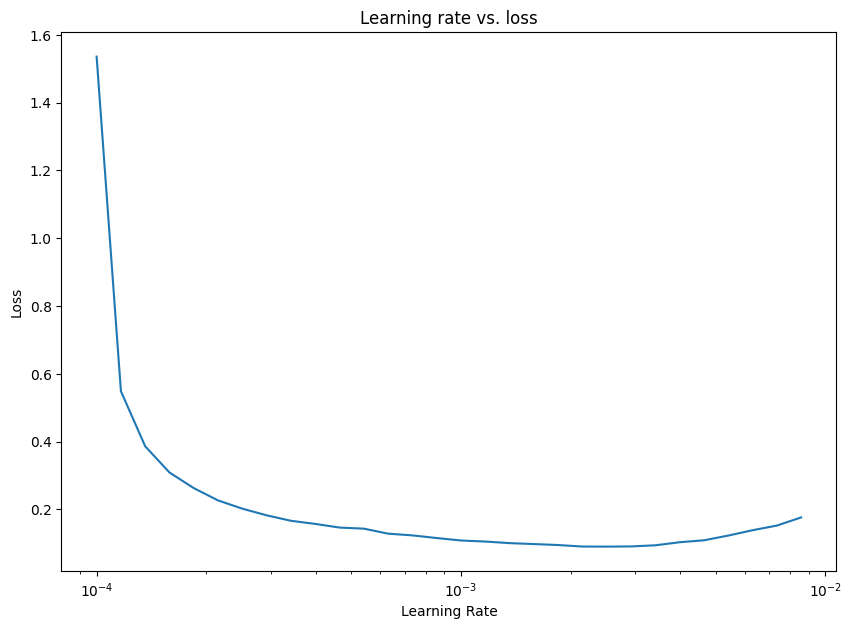

In [155]:
lrs = 1e-4 * (10 ** (np.arange(30)/15))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history_lr.history["loss"]) 
plt.xlabel("Learning Rate") 
plt.ylabel("Loss")
plt.title("Learning rate vs. loss");

As per the graph above, the ideal learning rate for a model trained on **RAW DATA** is around ``learning_rate = 3.5e-4``

#### **Ideal Learning Rate for Normalized Data**

In [156]:
tf.random.set_seed(42)

model_lr = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=16,
                           kernel_size=(3, 3),
                           activation='relu',
                           input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=32,
                           kernel_size=(3, 3),
                           activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    tf.keras.layers.GlobalAveragePooling2D(),
    
    tf.keras.layers.Dense(128, 
                          activation="relu"),
    tf.keras.layers.Dense(10, 
                          activation='softmax')
])

model_lr.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              metrics=['sparse_categorical_accuracy'])

lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/15))

history_lr = model_lr.fit(train_data_normalized, train_labels, 
                    epochs=30,
                    callbacks=[lr_callback])  

Epoch 1/30


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  11/1875 [..............................] - ETA: 10s - loss: 2.3006 - sparse_categorical_accuracy: 0.1193  

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1875/1875 [==============================] - 14s 7ms/step - loss: 2.0026 - sparse_categorical_accuracy: 0.3022 - lr: 1.0000e-04
Epoch 2/30
1875/1875 [==============================] - 11s 6ms/step - loss: 1.3610 - sparse_categorical_accuracy: 0.5701 - lr: 1.1659e-04
Epoch 3/30
1875/1875 [==============================] - 11s 6ms/step - loss: 0.9523 - sparse_categorical_accuracy: 0.7222 - lr: 1.3594e-04
Epoch 4/30
1875/1875 [==============================] - 12s 6ms/step - loss: 0.7079 - sparse_categorical_accuracy: 0.7919 - lr: 1.5849e-04
Epoch 5/30
1875/1875 [==============================] - 11s 6ms/step - loss: 0.5866 - sparse_categorical_accuracy: 0.8226 - lr: 1.8478e-04
Epoch 6/30
1875/1875 [==============================] - 12s 7ms/step - loss: 0.5150 - sparse_categorical_accuracy: 0.8402 - lr: 2.1544e-04
Epoch 7/30
1875/1875 [==============================] - 11s 6ms/step - loss: 0.4632 - sparse_categorical_accuracy: 0.8568 - lr: 2.5119e-04
Epoch 8/30
1875/1875 [================

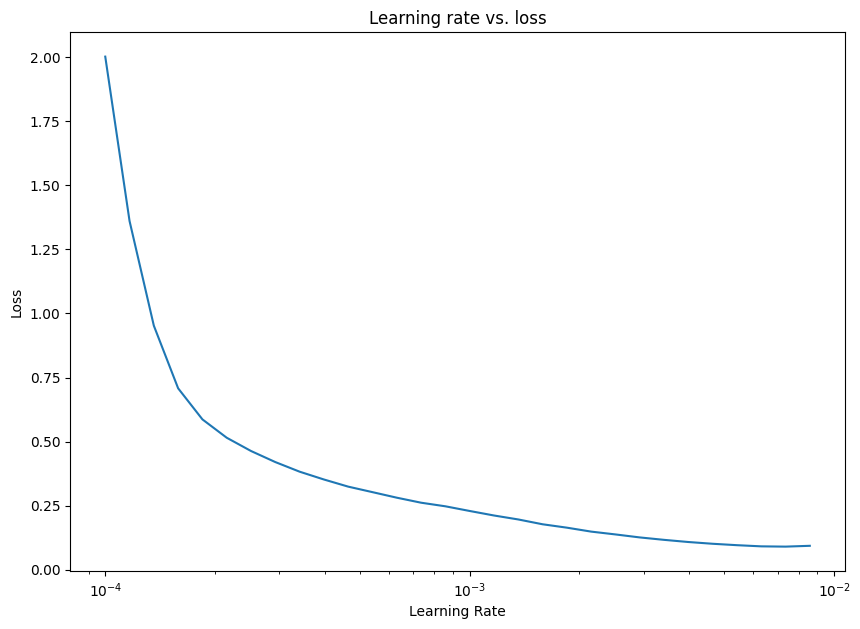

In [157]:
lrs = 1e-4 * (10 ** (np.arange(30)/15))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history_lr.history["loss"]) 
plt.xlabel("Learning Rate") 
plt.ylabel("Loss")
plt.title("Learning rate vs. loss");

As per the graph above, the ideal learning rate for a model trained on **NORMALIZED DATA** is around ``learning_rate = 0.002``

### **Create the Model**

#### **Model Trained on Raw Data**

In [169]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=16,
                           kernel_size=(3, 3),
                           activation='relu',
                           input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=32,
                           kernel_size=(3, 3),
                           activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    tf.keras.layers.GlobalAveragePooling2D(), 
    
    tf.keras.layers.Dense(128, 
                          activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, 
                          activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=3.5e-4),
              metrics=['sparse_categorical_accuracy'])

history = model.fit(train_data, train_labels, 
                    epochs=15,
                    validation_data=(test_data, test_labels))

Epoch 1/15


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

   9/1875 [..............................] - ETA: 12s - loss: 17.7906 - sparse_categorical_accuracy: 0.1354  

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1875/1875 [==============================] - 17s 8ms/step - loss: 0.9902 - sparse_categorical_accuracy: 0.7309 - val_loss: 0.2853 - val_sparse_categorical_accuracy: 0.9157
Epoch 2/15
1875/1875 [==============================] - 14s 8ms/step - loss: 0.2936 - sparse_categorical_accuracy: 0.9101 - val_loss: 0.2005 - val_sparse_categorical_accuracy: 0.9394
Epoch 3/15
1875/1875 [==============================] - 14s 7ms/step - loss: 0.2168 - sparse_categorical_accuracy: 0.9346 - val_loss: 0.1492 - val_sparse_categorical_accuracy: 0.9555
Epoch 4/15
1875/1875 [==============================] - 13s 7ms/step - loss: 0.1838 - sparse_categorical_accuracy: 0.9435 - val_loss: 0.1200 - val_sparse_categorical_accuracy: 0.9620
Epoch 5/15
1875/1875 [==============================] - 14s 7ms/step - loss: 0.1547 - sparse_categorical_accuracy: 0.9529 - val_loss: 0.1251 - val_sparse_categorical_accuracy: 0.9599
Epoch 6/15
1875/1875 [==============================] - 13s 7ms/step - loss: 0.1383 - sparse_cat

In [170]:
model.summary()

Model: "sequential_39"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_78 (Conv2D)          (None, 26, 26, 16)        160       
                                                                 
 max_pooling2d_78 (MaxPooli  (None, 13, 13, 16)        0         
 ng2D)                                                           
                                                                 
 conv2d_79 (Conv2D)          (None, 11, 11, 32)        4640      
                                                                 
 max_pooling2d_79 (MaxPooli  (None, 5, 5, 32)          0         
 ng2D)                                                           
                                                                 
 global_average_pooling2d_3  (None, 32)                0         
 9 (GlobalAveragePooling2D)                                      
                                                     

#### **Model Trained on Normalized Data**

In [222]:
tf.random.set_seed(42)

model_normalized = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=16,
                           kernel_size=(3, 3),
                           activation='relu',
                           input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(filters=32,
                           kernel_size=(3, 3),
                           activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    tf.keras.layers.GlobalAveragePooling2D(),
    
    tf.keras.layers.Dense(128, 
                          activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, 
                          activation='softmax')
])

model_normalized.compile(loss='sparse_categorical_crossentropy',
                        optimizer=tf.keras.optimizers.Adam(learning_rate=0.002175),
                        metrics=['sparse_categorical_accuracy'])

history_normalized = model_normalized.fit(train_data_normalized, train_labels, 
                                          epochs=15,
                                          validation_data=(test_data_normalized, test_labels))

Epoch 1/15


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

   9/1875 [..............................] - ETA: 11s - loss: 2.3044 - sparse_categorical_accuracy: 0.0972  

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1875/1875 [==============================] - 17s 8ms/step - loss: 0.8408 - sparse_categorical_accuracy: 0.7061 - val_loss: 0.3373 - val_sparse_categorical_accuracy: 0.8917
Epoch 2/15
1875/1875 [==============================] - 13s 7ms/step - loss: 0.3268 - sparse_categorical_accuracy: 0.8979 - val_loss: 0.2645 - val_sparse_categorical_accuracy: 0.9114
Epoch 3/15
1875/1875 [==============================] - 14s 7ms/step - loss: 0.2295 - sparse_categorical_accuracy: 0.9297 - val_loss: 0.1625 - val_sparse_categorical_accuracy: 0.9508
Epoch 4/15
1875/1875 [==============================] - 13s 7ms/step - loss: 0.1883 - sparse_categorical_accuracy: 0.9415 - val_loss: 0.1517 - val_sparse_categorical_accuracy: 0.9545
Epoch 5/15
1875/1875 [==============================] - 14s 8ms/step - loss: 0.1626 - sparse_categorical_accuracy: 0.9505 - val_loss: 0.1126 - val_sparse_categorical_accuracy: 0.9647
Epoch 6/15
1875/1875 [==============================] - 13s 7ms/step - loss: 0.1462 - sparse_cat

In [172]:
model_normalized.summary()

Model: "sequential_40"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_80 (Conv2D)          (None, 26, 26, 16)        160       
                                                                 
 max_pooling2d_80 (MaxPooli  (None, 13, 13, 16)        0         
 ng2D)                                                           
                                                                 
 conv2d_81 (Conv2D)          (None, 11, 11, 32)        4640      
                                                                 
 max_pooling2d_81 (MaxPooli  (None, 5, 5, 32)          0         
 ng2D)                                                           
                                                                 
 global_average_pooling2d_4  (None, 32)                0         
 0 (GlobalAveragePooling2D)                                      
                                                     

### **Display Results**

In [223]:
num_label = np.unique(train_labels)

def make_confusion_matrix(
    y_true,
    y_pred,
    classes=None,
    figsize=(8, 8),
    text_size=15,
    title="Confusion Matrix"
):
  """Makes a labelled confusion matrix comparing predictions and truth labels."""
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
  n_classes = cm.shape[0]

  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues)
  fig.colorbar(cax)

  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  ax.set(title=title,
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes),
         yticks=np.arange(n_classes),
         xticklabels=labels,
         yticklabels=labels)

  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  threshold = (cm.max() + cm.min()) / 2.

  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j] * 100:.1f}%)",
             horizontalalignment="center",
             color="white" if cm[i, j] > threshold else "black",
             size=text_size)


In [224]:
def plot_image(model, images, true_labels, classes, index):
  """Plots a single image and labels it with a predicted and truth label.

  Args:
    model: a trained model (trained on data similar to what's in images).
    images: image array to select from.
    true_labels: array of ground truth labels for images.
    classes: array of class names for images.
    index: index of the image to plot.

  Returns:
    A plot of the image at index `index`.
  """
  target_image = images[index]
  true_label = classes[true_labels[index]]

  pred_probs = model.predict(tf.expand_dims(target_image, axis=0), verbose=0)
  pred_label = classes[pred_probs.argmax()]

  plt.imshow(target_image, cmap=plt.cm.binary) 

  if pred_label == true_label:
    color = "green"
  else:
    color = "red"

  plt.xlabel(
      f"Pred: {pred_label} {100 * tf.reduce_max(pred_probs):.2f}% | True: {true_label}",
      color=color
  )

#### **Accuracy / Loss Graph**

Text(0.5, 1.0, 'Model w/ Normalized Data')

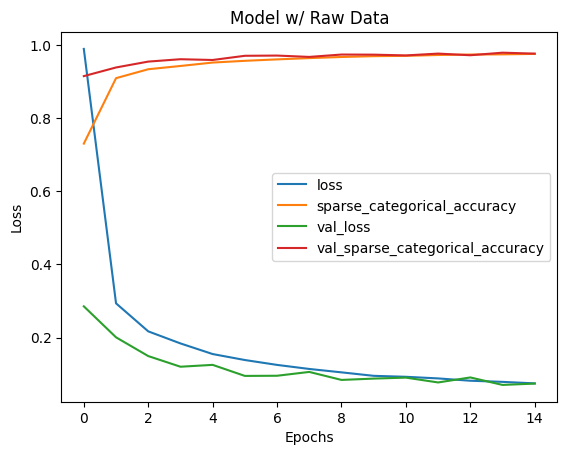

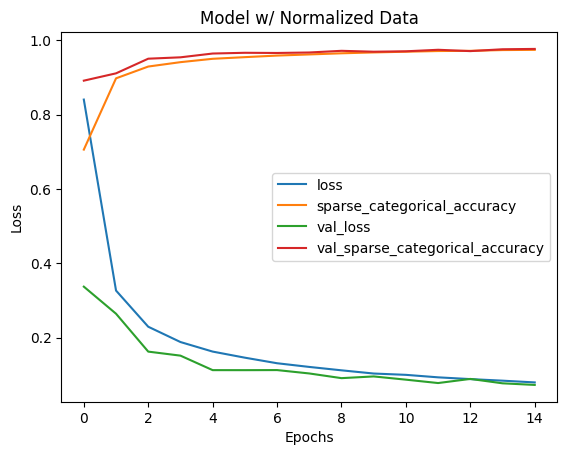

In [225]:
pd.DataFrame(history.history).plot() 
mpl.pyplot.xlabel('Epochs')
mpl.pyplot.ylabel('Loss')
mpl.pyplot.title('Model w/ Raw Data')


pd.DataFrame(history_normalized.history).plot()
mpl.pyplot.xlabel('Epochs')
mpl.pyplot.ylabel('Loss')
mpl.pyplot.title('Model w/ Normalized Data')

#### **Confusion Matrics**

313/313 [==============================] - 1s 3ms/step


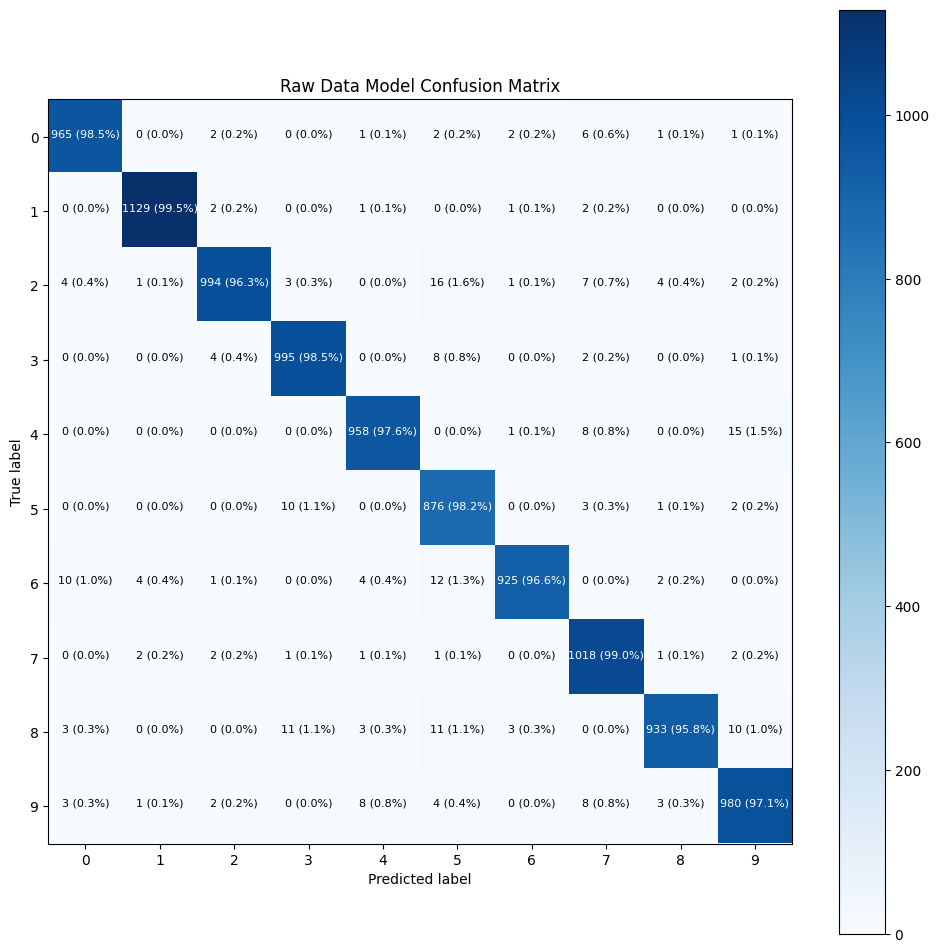

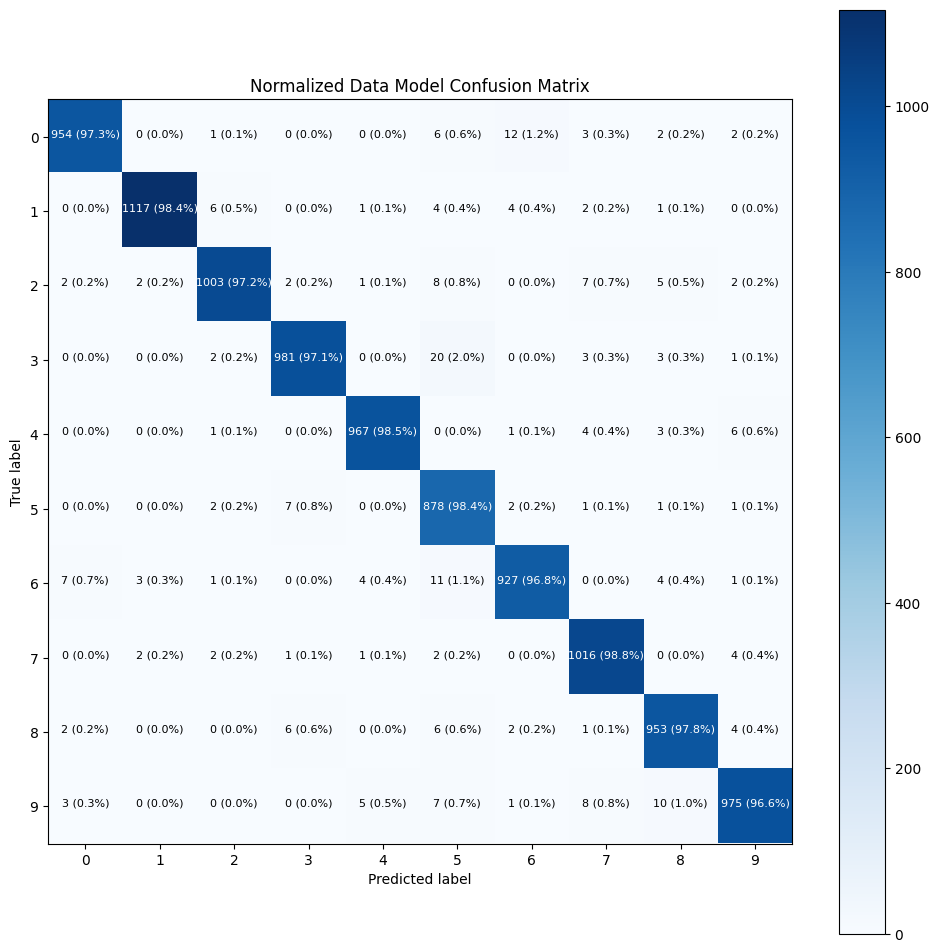

In [226]:
make_confusion_matrix(y_true=test_labels,
                      y_pred=(model.predict(test_data)).argmax(axis=1),
                      classes=list(num_label),
                      figsize=(12, 12),
                      text_size=8,
                      title="Raw Data Model Confusion Matrix")

make_confusion_matrix(y_true=test_labels,
                      y_pred=(model_normalized.predict(test_data_normalized)).argmax(axis=1),
                      classes=list(num_label),
                      figsize=(12, 12),
                      text_size=8,
                      title="Normalized Data Model Confusion Matrix")

#### **Normalized vs Raw Training Sets Predictions**

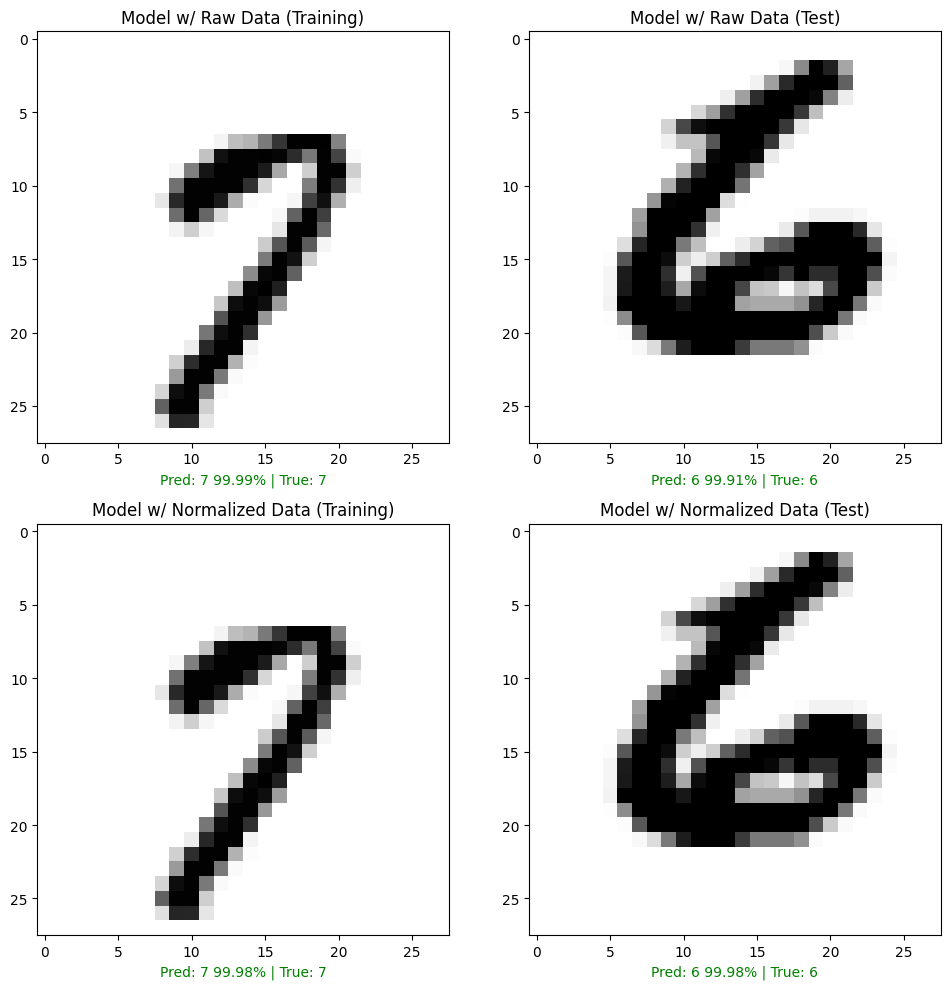

In [227]:
comparison_index = len(test_data) - 1

plt.figure(figsize=(10, 10))

plots = [
    ('Model w/ Raw Data (Training)', model, train_data, train_labels, comparison_index),
    ('Model w/ Raw Data (Test)', model, test_data, test_labels, comparison_index),
    ('Model w/ Normalized Data (Training)', model_normalized, train_data_normalized, train_labels, comparison_index),
    ('Model w/ Normalized Data (Test)', model_normalized, test_data_normalized, test_labels, comparison_index)
]

for i, (title, selected_model, img_data, labels, index) in enumerate(plots):
    plt.subplot(2, 2, i + 1)
    plt.title(title)

    plot_image(
        selected_model,
        img_data,
        labels,
        list(num_label),
        index
    )

plt.tight_layout()

**Prediction Evaluation Comparison**

In [228]:
raw_out = model.evaluate(test_data, test_labels)
norm_out = model_normalized.evaluate(test_data_normalized, test_labels)
print(f'Model w/ Raw Data: Loss: {round((raw_out[0]*100),2)}%  Accuracy: {round((raw_out[1]*100),2)}%')
print(f'Model w/ Normalized Data: Loss: {round((norm_out[0]*100),2)}%  Accuracy: {round((norm_out[1]*100),2)}%')

313/313 [==============================] - 1s 5ms/step - loss: 0.0728 - sparse_categorical_accuracy: 0.9771
Model w/ Raw Data: Loss: 7.38%  Accuracy: 97.73%
Model w/ Normalized Data: Loss: 7.28%  Accuracy: 97.71%
